### Kernel: R

## Avaliar as curvas de sobrevivência de cada modelo para os subgrupos da árvore aleatória ajustada na etapa de seleção de covariáveis do estudo anterior.

In [19]:
# Carregamento de pacotes

library(pacman)
p_load(dplyr, tidyr, readr, ggplot2, survival, broom)

In [20]:
# Devisão das covariáveis de acordo com os subgrupos definidos pela árvore do artigo
vars_paper <- c(
  "stage_paper",
  "prior_diag_trat_paper",
  "hormonioterapia_paper",
  "educ_paper",
  "quimioterapia_paper",
  "macroregiao_paper"
)

prepara_base <- function(df) {
  df %>%
    select(
      id_paciente,
      tempo,
      delta_t,
      rhc_estadiamento_clinico,
      rhc_diagnostico_e_tratamentos_anteriores,
      rhc_primeiro_tratamento_recebido_no_hospital_hormonioterapia,
      rhc_primeiro_tratamento_recebido_no_hospital_quimioterapia,
      instrucao,
      macroregiao
    ) %>%
    mutate(
      id_paciente = as.numeric(id_paciente),
      tempo = as.numeric(tempo),
      delta_t = as.numeric(delta_t),
      stage_paper = case_when(
        rhc_estadiamento_clinico == "I e II" ~ "I/II",
        rhc_estadiamento_clinico == "III e IV" ~ "III/IV",
        TRUE ~ NA_character_
      ),
      prior_diag_trat_paper = case_when(
        rhc_diagnostico_e_tratamentos_anteriores == "Com diag./Com trat." ~ "Com diag./Com trat.",
        rhc_diagnostico_e_tratamentos_anteriores %in% c("Com diag./Sem trat.", "Sem diag./Sem trat.") ~ "Outros",
        TRUE ~ NA_character_
      ),
      hormonioterapia_paper = case_when(
        rhc_primeiro_tratamento_recebido_no_hospital_hormonioterapia == "Sim" ~ "Sim",
        rhc_primeiro_tratamento_recebido_no_hospital_hormonioterapia == "Nao" ~ "Nao",
        rhc_primeiro_tratamento_recebido_no_hospital_hormonioterapia == "Não" ~ "Nao",
        TRUE ~ NA_character_
      ),
      quimioterapia_paper = case_when(
        rhc_primeiro_tratamento_recebido_no_hospital_quimioterapia == "Sim" ~ "Sim",
        rhc_primeiro_tratamento_recebido_no_hospital_quimioterapia == "Nao" ~ "Nao",
        rhc_primeiro_tratamento_recebido_no_hospital_quimioterapia == "Não" ~ "Nao",
        TRUE ~ NA_character_
      ),
      educ_paper = case_when(
        instrucao == 0 ~ "None",
        instrucao %in% c(1, 2) ~ "Primary/Secondary+",
        TRUE ~ NA_character_
      ),
      educ_tree = case_when(
        instrucao == 0 ~ "None",
        instrucao == 1 ~ "Primary",
        instrucao == 2 ~ "Secondary+",
        TRUE ~ NA_character_
      ),
      macroregiao_paper = case_when(
        macroregiao == 2 ~ "2",
        macroregiao %in% c(1, 3) ~ "1/3",
        TRUE ~ NA_character_
      )
    ) %>%
    mutate(
      stage_paper = factor(stage_paper, levels = c("I/II", "III/IV")),
      prior_diag_trat_paper = factor(prior_diag_trat_paper, levels = c("Com diag./Com trat.", "Outros")),
      hormonioterapia_paper = factor(hormonioterapia_paper, levels = c("Sim", "Nao")),
      educ_paper = factor(educ_paper, levels = c("None", "Primary/Secondary+")),
      educ_tree = factor(educ_tree, levels = c("None", "Primary", "Secondary+")),
      quimioterapia_paper = factor(quimioterapia_paper, levels = c("Sim", "Nao")),
      macroregiao_paper = factor(macroregiao_paper, levels = c("2", "1/3"))
    ) %>%
    filter(tempo > 0, !is.na(delta_t)) %>%
    drop_na(all_of(vars_paper)) %>%
    select(id_paciente, tempo, delta_t, all_of(vars_paper), educ_tree)
}

In [21]:
# Carregamento e preparação dos dados de teste
dados_teste <- read_csv("../dados/dados-processados/dados_teste.csv", show_col_types = FALSE)
dados_teste_modelo <- prepara_base(dados_teste)

In [22]:
# Criação dos subgrupos de acordo com a árvore do artigo

atribuir_grupo <- function(df) {
  df %>%
    mutate(
      grupo = case_when(
        stage_paper == "I/II" & educ_tree %in% c("None", "Primary") &
          hormonioterapia_paper == "Nao" & educ_tree == "None" ~ "Grupo 1",
        stage_paper == "I/II" & educ_tree %in% c("None", "Primary") &
          hormonioterapia_paper == "Nao" & educ_tree == "Primary" ~ "Grupo 2",
        stage_paper == "I/II" & educ_tree %in% c("None", "Primary") &
          hormonioterapia_paper == "Sim" ~ "Grupo 3",
        stage_paper == "I/II" & educ_tree == "Secondary+" ~ "Grupo 4",
        stage_paper == "III/IV" & prior_diag_trat_paper == "Outros" &
          educ_tree == "None" ~ "Grupo 5",
        stage_paper == "III/IV" & prior_diag_trat_paper == "Outros" &
          educ_tree %in% c("Primary", "Secondary+") ~ "Grupo 6",
        stage_paper == "III/IV" & prior_diag_trat_paper == "Com diag./Com trat." &
          hormonioterapia_paper == "Nao" & quimioterapia_paper == "Nao" ~ "Grupo 7",
        stage_paper == "III/IV" & prior_diag_trat_paper == "Com diag./Com trat." &
          hormonioterapia_paper == "Nao" & quimioterapia_paper == "Sim" ~ "Grupo 8",
        stage_paper == "III/IV" & prior_diag_trat_paper == "Com diag./Com trat." &
          hormonioterapia_paper == "Sim" ~ "Grupo 9",
        TRUE ~ NA_character_
      ),
      grupo = factor(grupo, levels = paste("Grupo", 1:9))
    )
}

dados_teste_modelo <- atribuir_grupo(dados_teste_modelo)

In [23]:
head(dados_teste_modelo)

id_paciente,tempo,delta_t,stage_paper,prior_diag_trat_paper,hormonioterapia_paper,educ_paper,quimioterapia_paper,macroregiao_paper,educ_tree,grupo
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
3,1,1,III/IV,Outros,Nao,None,Nao,1/3,None,Grupo 5
4,13,1,III/IV,Outros,Nao,None,Sim,2,None,Grupo 5
9,84,1,I/II,Outros,Nao,Primary/Secondary+,Sim,1/3,Primary,Grupo 2
11,75,1,III/IV,Outros,Sim,Primary/Secondary+,Sim,1/3,Primary,Grupo 6
14,8,1,I/II,Outros,Nao,Primary/Secondary+,Sim,2,Primary,Grupo 2
15,49,1,III/IV,Outros,Sim,Primary/Secondary+,Sim,1/3,Primary,Grupo 6


## Predicoes dos modelos

In [24]:
# Leitura dos arquivos de saida

pred_cox <- read_csv("../ajuste-modelos/cox-cura/dados/saida/predicao_cox.csv", show_col_types = FALSE)
pred_cura <- read_csv("../ajuste-modelos/cox-cura/dados/saida/predicao_cura.csv", show_col_types = FALSE)
pred_deepsurv_covsel <- read_csv("../ajuste-modelos/deepsurv/dados/saida/predicao-deepsurv-covariaveis-selecionadas.csv", show_col_types = FALSE)
pred_rede_A_covsel <- read_csv("../ajuste-modelos/pseudo-sobrevivencia-total/dados/saida/predicao-rede-A-onehot-covsel.csv", show_col_types = FALSE)
pred_rede_B_covsel <- read_csv("../ajuste-modelos/pseudo-sobrevivencia-total/dados/saida/predicao-rede-B-tempo-continuo-covsel.csv", show_col_types = FALSE)

# Experimentos complementares
pred_rede_A <- read_csv("../experimentos-complementares/pseudo/sobrevivencia-total/dados/saida/predicao-rede-A-onehot.csv", show_col_types = FALSE)
pred_rede_B <- read_csv("../experimentos-complementares/pseudo/sobrevivencia-total/dados/saida/predicao-rede-B-tempo-continuo.csv", show_col_types = FALSE)
pred_rede_C <- read_csv("../experimentos-complementares/pseudo/sobrevivencia-total/dados/saida/predicao-rede-C-optuna.csv", show_col_types = FALSE)
pred_deepsurv <- read_csv("../experimentos-complementares/deepsurv/dados/saida/predicao-deepsurv.csv", show_col_types = FALSE)
pred_deepsurv_optuna <- read_csv("../experimentos-complementares/deepsurv/dados/saida/predicao-deepsurv-optuna.csv", show_col_types = FALSE)
pred_deepsurv_optuna_covsel <- read_csv("../experimentos-complementares/deepsurv/dados/saida/predicao-deepsurv-optuna-covariaveis-selecionadas.csv", show_col_types = FALSE)
pred_rede_lat_inc <- read_csv("../experimentos-complementares/pseudo/latencia-incidencia/dados/saida/predicao-rede-lat-inc.csv", show_col_types = FALSE)
pred_rede_lat_inc_covsel <- read_csv("../experimentos-complementares/pseudo/latencia-incidencia/dados/saida/predicao-rede-lat-inc-covsel.csv", show_col_types = FALSE)

In [25]:
padroniza_pred <- function(df, nome_modelo) {
  df %>%
    transmute(
      id_paciente = as.numeric(ID),
      tempo = as.numeric(TIME),
      pred = as.numeric(PRED_S),
      modelo = nome_modelo
    )
}

pred_long <- bind_rows(
  padroniza_pred(pred_cox, "cox"),
  padroniza_pred(pred_cura, "cura"),
  padroniza_pred(pred_deepsurv_covsel, "deepsurv_covsel"),
  padroniza_pred(pred_rede_A_covsel, "rede_A_onehot_covsel"),
  padroniza_pred(pred_rede_B_covsel, "rede_B_continuo_covsel"),
  # Experimentos complementares
  padroniza_pred(pred_rede_A, "rede_A_onehot"),
  padroniza_pred(pred_rede_B, "rede_B_continuo"),
  padroniza_pred(pred_rede_C, "rede_C_optuna"),
  padroniza_pred(pred_deepsurv, "deepsurv"),
  padroniza_pred(pred_deepsurv_optuna, "deepsurv_optuna"),
  padroniza_pred(pred_deepsurv_optuna_covsel, "deepsurv_optuna_covsel"),
  padroniza_pred(pred_rede_lat_inc, "rede_lat_inc"),
  padroniza_pred(pred_rede_lat_inc_covsel, "rede_lat_inc_covsel")
)

## Curvas por subgrupo
KM como referencia e media das curvas previstas por modelo.

grupo,n
<fct>,<int>
Grupo 1,75
Grupo 2,315
Grupo 3,268
Grupo 4,112
Grupo 5,99
Grupo 6,328
Grupo 7,14
Grupo 8,1
Grupo 9,3


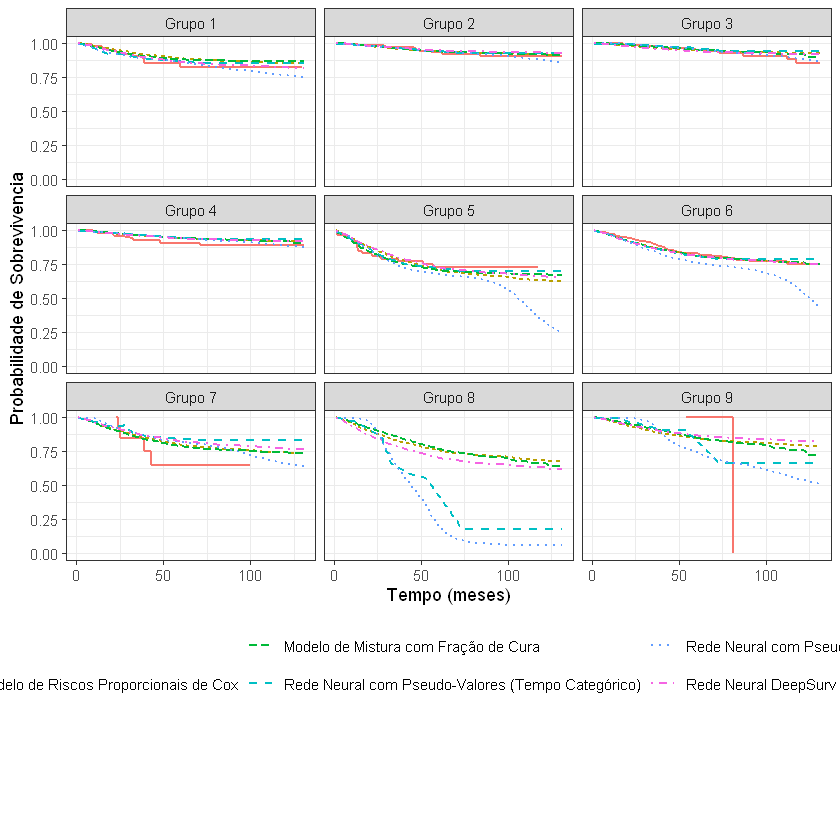

In [26]:
subgrupos <- dados_teste_modelo %>%
  select(id_paciente, tempo, delta_t, grupo)

grupo_counts <- subgrupos %>%
  count(grupo, name = "n") %>%
  arrange(grupo)

grupo_counts

pred_medias <- pred_long %>%
  left_join(subgrupos %>% select(id_paciente, grupo), by = "id_paciente") %>%
  filter(!is.na(grupo)) %>%
  group_by(grupo, modelo, tempo) %>%
  summarise(pred = mean(pred, na.rm = TRUE), .groups = "drop")

km_curvas <- dados_teste_modelo %>%
  filter(!is.na(grupo)) %>%
  group_by(grupo) %>%
  group_modify(~ {
    fit <- survfit(Surv(tempo, delta_t) ~ 1, data = .x)
    broom::tidy(fit) %>% select(time, estimate)
  }) %>%
  ungroup() %>%
  transmute(grupo, tempo = time, pred = estimate, modelo = "KM")

curvas_plot <- bind_rows(km_curvas, pred_medias) %>%
  mutate(modelo_novo = case_when(
    modelo == "KM" ~ "KM",
    modelo == "cox" ~ "Modelo de Riscos Proporcionais de Cox",
    modelo == "cura" ~ "Modelo de Mistura com Fração de Cura",
    modelo == "rede_A_onehot_covsel" ~ "Rede Neural com Pseudo-Valores (Tempo Categórico)",
    modelo == "rede_B_continuo_covsel" ~ "Rede Neural com Pseudo-Valores (Tempo Contínuo)",
    modelo == "deepsurv_covsel" ~ "Rede Neural DeepSurv",
    TRUE ~ NA_character_
  )) %>%
  filter(!is.na(modelo_novo)) %>%
  mutate(modelo = factor(modelo_novo, levels = c(
    "KM",
    "Modelo de Riscos Proporcionais de Cox",
    "Modelo de Mistura com Fração de Cura",
    "Rede Neural com Pseudo-Valores (Tempo Categórico)",
    "Rede Neural com Pseudo-Valores (Tempo Contínuo)",
    "Rede Neural DeepSurv"
  ))) %>%
  select(-modelo_novo)

p1 <- ggplot(curvas_plot, aes(x = tempo, y = pred, color = modelo, linetype = modelo)) +
  geom_step(linewidth = 0.6) +
  facet_wrap(~ grupo, ncol = 3) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(
    x = "Tempo (meses)",
    y = "Probabilidade de Sobrevivencia",
    color = "Modelo",
    linetype = "Modelo"
  ) +
  theme_bw() +
  theme(legend.position = "bottom", 
        plot.margin = margin(t = 5, r = 5, b = 80, l = 5, unit = "pt"))

p1

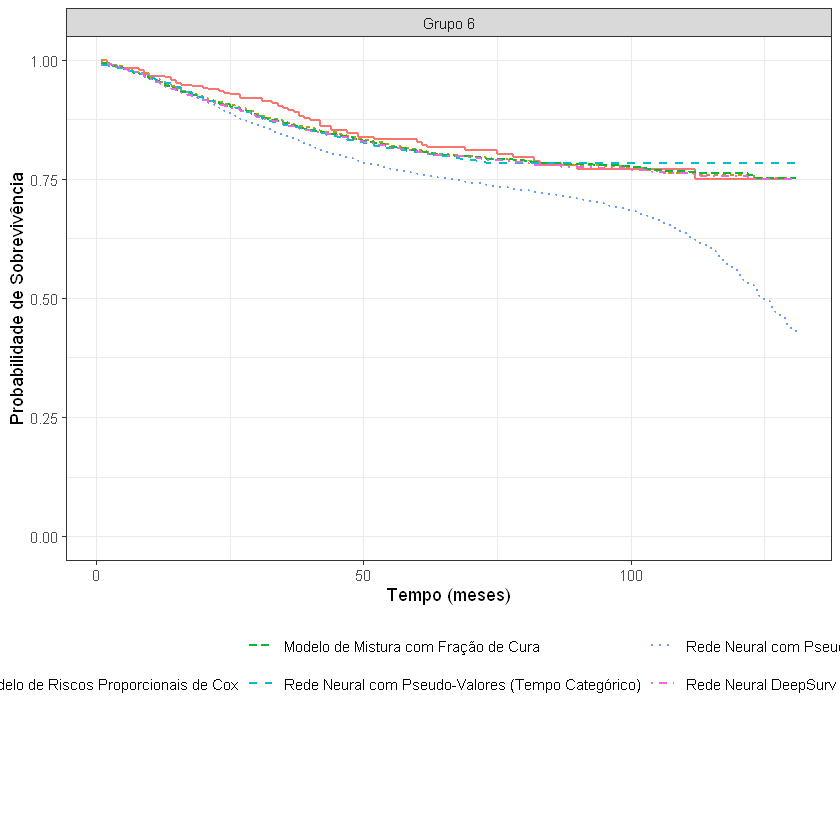

In [28]:
# Avaliação visual das curvas escolhendo-se um grupo específico (exemplo: Grupo 6)

grupo_especifico <- "Grupo 6"   
curvas_plot_grupo_especifico <- curvas_plot %>%
  filter(grupo == grupo_especifico)

p2 <- ggplot(curvas_plot_grupo_especifico, aes(x = tempo, y = pred, color = modelo, linetype = modelo)) +
  geom_step(linewidth = 0.6) +
  facet_wrap(~ grupo, ncol = 3) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(
    x = "Tempo (meses)",
    y = "Probabilidade de Sobrevivência",
    color = "Modelo",
    linetype = "Modelo"
  ) +
  theme_bw() +
  theme(legend.position = "bottom", 
        plot.margin = margin(t = 5, r = 5, b = 80, l = 5, unit = "pt"))

p2